# Pulling Dataset

In [3]:
import pandas as pd

df_1 = pd.read_csv("Training.csv")
df_1.head(5)

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,0,39.0,14.0,5.0,18.0,2,0,932.0,17.0,1.0
1,3.0,65.0,0,49.0,1.0,10.0,8.0,0,1,557.0,6.0,1.0
2,4.0,55.0,0,14.0,4.0,6.0,18.0,0,2,185.0,3.0,1.0
3,5.0,58.0,1,38.0,21.0,7.0,7.0,2,1,396.0,29.0,1.0
4,6.0,23.0,1,32.0,20.0,5.0,8.0,0,1,617.0,20.0,1.0


In [4]:
df_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440833 entries, 0 to 440832
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440832 non-null  float64
 1   Age                440832 non-null  float64
 2   Gender             440833 non-null  int64  
 3   Tenure             440832 non-null  float64
 4   Usage Frequency    440832 non-null  float64
 5   Support Calls      440832 non-null  float64
 6   Payment Delay      440832 non-null  float64
 7   Subscription Type  440833 non-null  int64  
 8   Contract Length    440833 non-null  int64  
 9   Total Spend        440832 non-null  float64
 10  Last Interaction   440832 non-null  float64
 11  Churn              440832 non-null  float64
dtypes: float64(9), int64(3)
memory usage: 40.4 MB


In [5]:
df_1.describe()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
count,440832.000000,440832.000000,440833.000000,440832.000000,440832.000000,440832.000000,440832.000000,440833.000000,440833.000000,440832.000000,440832.000000,440832.000000
mean,225398.667955,39.373153,0.567684,31.256336,15.807494,3.604437,12.965722,1.013847,0.998489,631.616223,14.480868,0.567107
std,129531.918550,12.442369,0.495403,17.255727,8.586242,3.070218,8.258063,0.813972,0.895777,240.803001,8.596208,0.495477
min,2.000000,18.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,113621.750000,29.000000,0.000000,16.000000,9.000000,1.000000,6.000000,0.000000,0.000000,480.000000,7.000000,0.000000
50%,226125.500000,39.000000,1.000000,32.000000,16.000000,3.000000,12.000000,1.000000,1.000000,661.000000,14.000000,1.000000
75%,337739.250000,48.000000,1.000000,46.000000,23.000000,6.000000,19.000000,2.000000,2.000000,830.000000,22.000000,1.000000
max,449999.000000,65.000000,2.000000,60.000000,30.000000,10.000000,30.000000,3.000000,3.000000,1000.000000,30.000000,1.000000


In [6]:
df_1['Churn'].value_counts()

,count
Churn,
1.0,249999
0.0,190833


## Handling missing values

In [7]:
from sklearn.impute import SimpleImputer
import pandas as pd

# Separate numeric columns and categorical columns
numeric_columns = df_1.select_dtypes(include=['number']).columns
categorical_columns = df_1.select_dtypes(exclude=['number']).columns

# Apply SimpleImputer to numeric columns with strategy 'median'
imputer = SimpleImputer(strategy='median')  # Using 'median' to fill missing values
df_1[numeric_columns] = imputer.fit_transform(df_1[numeric_columns])

# For categorical columns, just leave missing values as NaN
# No need to fill missing values in categorical columns if you want to keep them as NaN
df_1[categorical_columns] = df_1[categorical_columns].apply(lambda x: x.fillna(pd.NA))

In [8]:
print(df_1.isnull().sum())

CustomerID           0
Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64


## Label Encoding

In [9]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Load the training and testing CSV files
df_1 = pd.read_csv('Training.csv')  # Replace with the path to your training CSV file
df_2 = pd.read_csv('Testing.csv')   # Replace with the path to your testing CSV file

# Define the categorical columns that need encoding
categorical_columns = ['Gender', 'Subscription Type', 'Contract Length']

# Apply label encoding for the specified categorical columns
for column in categorical_columns:
    if column in df_1.columns:  # Check if the column exists in the training dataset
        label_encoder = LabelEncoder()  # Initialize a new encoder
        df_1[column] = label_encoder.fit_transform(df_1[column])  # Encode the training data
        df_2[column] = label_encoder.transform(df_2[column])  # Apply the same transformation to the test data

# Save the modified DataFrames back to CSV files
df_1.to_csv('Training.csv', index=False)  # Overwrite the original training file
df_2.to_csv('Testing.csv', index=False)   # Overwrite the original testing file

print("Updated training data with encoded categorical features (without 'prognosis') saved to 'Training.csv'")
print("Updated testing data with encoded categorical features (without 'prognosis') saved to 'Testing.csv'")


Updated training data with encoded categorical features (without 'prognosis') saved to 'Training.csv'
Updated testing data with encoded categorical features (without 'prognosis') saved to 'Testing.csv'


# Step 1 ('imputer'): This step will fill any missing values in the categorical columns (like Gender, Subscription Type, etc.) with the value 'Unknown'.
# Step 2 ('encoder'): After missing values are handled, OneHotEncoder will convert the categorical data into binary vectors (1 or 0) for each category.

## Train Test Splitting

In [10]:
from sklearn.model_selection import train_test_split
train_set, test_set = train_test_split(df_1,test_size = 0.2, random_state = 42) # random state the shuffled values fixed for every run
print(f"The rows in train set is {len(train_set)}\nRows in test set is {len(test_set)}")

The rows in train set is 352666
Rows in test set is 88167


In [11]:
median = df_1['Tenure'].median() # Fill missing values in Tenure
df_1["Tenure"].fillna(median,inplace=True)

<ipython-input-11-5a4bd68717db>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_1["Tenure"].fillna(median,inplace=True)


In [12]:
from sklearn.model_selection import StratifiedShuffleSplit
split = StratifiedShuffleSplit(n_splits=1,test_size=0.2,random_state=42) # n_splits mean only one split
for train_index,test_index in split.split(df_1,df_1['Tenure']): # here choose that column which has equal no. of 0s and 1s which define this Shuffle
    strat_train_set = df_1.loc[train_index] # New Training set
    strat_test_set = df_1.loc[test_index]   # New Test set

In [13]:
strat_train_set.info()

<class 'pandas.core.frame.DataFrame'>
Index: 352666 entries, 400061 to 264325
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         352665 non-null  float64
 1   Age                352665 non-null  float64
 2   Gender             352666 non-null  int64  
 3   Tenure             352666 non-null  float64
 4   Usage Frequency    352665 non-null  float64
 5   Support Calls      352665 non-null  float64
 6   Payment Delay      352665 non-null  float64
 7   Subscription Type  352666 non-null  int64  
 8   Contract Length    352666 non-null  int64  
 9   Total Spend        352665 non-null  float64
 10  Last Interaction   352665 non-null  float64
 11  Churn              352665 non-null  float64
dtypes: float64(9), int64(3)
memory usage: 35.0 MB


In [14]:
strat_train_set['Tenure'].value_counts()

,count
Tenure,
32.0,6263
49.0,6252
56.0,6250
55.0,6222
33.0,6216
52.0,6215
30.0,6200
47.0,6198
48.0,6190


## Plotting

array([[<Axes: xlabel='Total Spend', ylabel='Total Spend'>,
        <Axes: xlabel='Churn', ylabel='Total Spend'>,
        <Axes: xlabel='Tenure', ylabel='Total Spend'>,
        <Axes: xlabel='Support Calls', ylabel='Total Spend'>],
       [<Axes: xlabel='Total Spend', ylabel='Churn'>,
        <Axes: xlabel='Churn', ylabel='Churn'>,
        <Axes: xlabel='Tenure', ylabel='Churn'>,
        <Axes: xlabel='Support Calls', ylabel='Churn'>],
       [<Axes: xlabel='Total Spend', ylabel='Tenure'>,
        <Axes: xlabel='Churn', ylabel='Tenure'>,
        <Axes: xlabel='Tenure', ylabel='Tenure'>,
        <Axes: xlabel='Support Calls', ylabel='Tenure'>],
       [<Axes: xlabel='Total Spend', ylabel='Support Calls'>,
        <Axes: xlabel='Churn', ylabel='Support Calls'>,
        <Axes: xlabel='Tenure', ylabel='Support Calls'>,
        <Axes: xlabel='Support Calls', ylabel='Support Calls'>]],
      dtype=object)

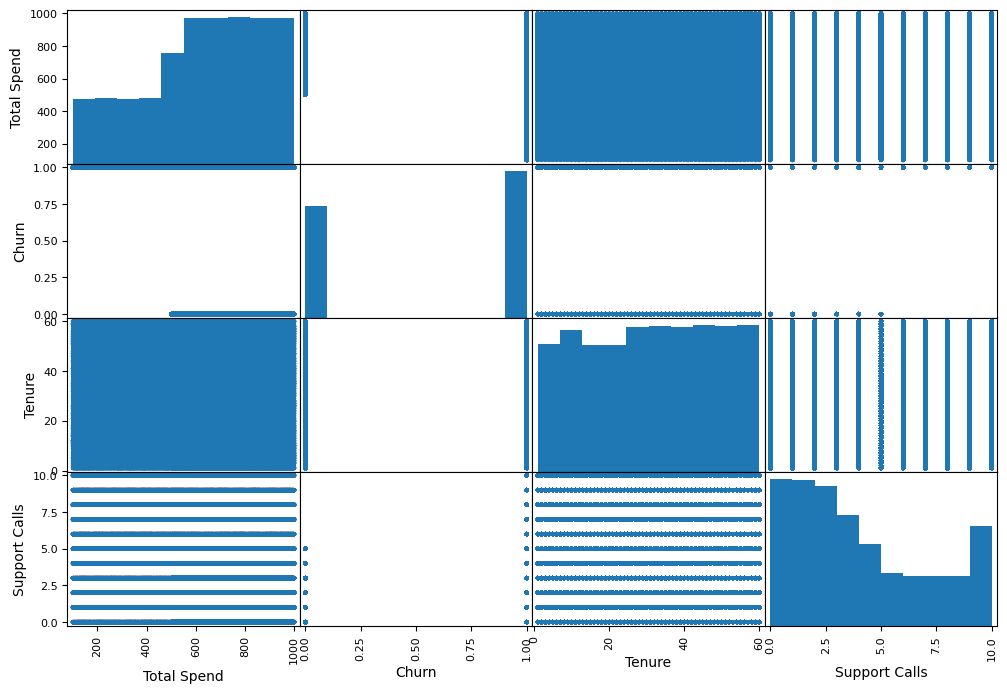

In [15]:
from pandas.plotting import scatter_matrix
attributes = ['Total Spend','Churn','Tenure','Support Calls'] # It gives us insights from data
# if not it take all 13X13 feature correlation
scatter_matrix(df_1[attributes],figsize=(12,8))

In [16]:
df_1 = strat_train_set.drop("Churn", axis=1)
df_labels = strat_train_set["Churn"].copy()

## Missing Values

## lambda x: A lambda function is an anonymous function, which in this case is applied to each column of the categorical data.
## x.fillna(pd.NA): This part fills missing values (NaN) with pd.NA (a special missing value indicator from Pandas).
## pd.NA is a Pandas-specific representation for missing data. It's more consistent and supports better operations for missing values compared to the older NaN (from numpy)

In [17]:
from sklearn.impute import SimpleImputer
import pandas as pd

# Separate numeric columns and categorical columns
numeric_columns = df_1.select_dtypes(include=['number']).columns
categorical_columns = df_1.select_dtypes(exclude=['number']).columns

# Apply SimpleImputer to numeric columns with strategy 'median'
imputer = SimpleImputer(strategy='median')  # Using 'median' to fill missing values
df_1[numeric_columns] = imputer.fit_transform(df_1[numeric_columns])

# For categorical columns, just leave missing values as NaN
# No need to fill missing values in categorical columns if you want to keep them as NaN
df_1[categorical_columns] = df_1[categorical_columns].apply(lambda x: x.fillna(pd.NA))

In [18]:
# Check the result
print(df_1.isnull().sum())  # To see how missing values are handled Where is 1 mean missing values which are filled as NAN

CustomerID           0
Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
dtype: int64


In [19]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
my_pipeline = Pipeline([
    ('imputer',SimpleImputer(strategy='median')), # Here we do imputing
    ('std_scaler',StandardScaler()), # here we do feature scaling
])


In [20]:
df_1_num_tr = my_pipeline.fit_transform(df_1)
df_1_num_tr.shape

(352666, 11)

## EDA(Exploartory Data analysis)

In [22]:
!pip install ydata_profiling

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 390.6/390.6 kB 23.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.5/296.5 kB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 686.1/686.1 kB 34.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.8/104.8 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 85.6 MB/s eta 0:00:00
  Created wheel for htmlmin: filename=htmlmin-0.1.12-py3-none-any.whl size=27081 sha256=afcca0bef008b798bc2e236ce42920e1984663ce6721ac2fee74c2d9712907a7
  Stored in directory: /root/.cache/pip/wheels/dd/91/29/a79cecb328d01739e64017b6fb9a1ab9d8cb1853098ec5966d
Successfully built htmlmin


In [23]:
import pandas as pd
from ydata_profiling import ProfileReport  # Ensure the correct import

# Load your data
df = pd.read_csv('Training.csv')

# Generate the report
profile = ProfileReport(df)
profile.to_file(output_file="Explorator_Data.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

## Seperating data and labels

In [26]:
from sklearn.impute import SimpleImputer

# Apply SimpleImputer to fill missing values in the target variable
imputer = SimpleImputer(strategy='most_frequent')  # Fill NaN values with the most frequent value
df_labels = imputer.fit_transform(df_labels.values.reshape(-1, 1))  # Reshape to 2D array

# Now df_labels should no longer contain NaN values


## Selecting a desired model

In [27]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier

# Define base learners
base_learners = [
    ('logistic', LogisticRegression(max_iter=100, random_state=42)),
    ('random_forest', RandomForestClassifier(n_estimators=100, random_state=42))
]

# Define the meta-learner
meta_learner = LogisticRegression(max_iter=100, random_state=42)

# Define the stacking classifier
stacking_model = StackingClassifier(estimators=base_learners, final_estimator=meta_learner, cv=5)

In [29]:

# Train the stacking model
stacking_model.fit(df_1_num_tr, df_labels)

print("Stacking model trained successfully!")


/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_label.py:97: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_label.py:132: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


Stacking model trained successfully!


In [31]:
some_data = df_1.iloc[:5] # Some data from Training set Not using testing data right now use when model finalize

In [32]:
import pandas as pd

# If df_labels is a numpy ndarray with shape (352666, 1), flatten it before converting to a pandas Series
df_labels = pd.Series(df_labels.ravel())  # or df_labels.flatten()

# Now use iloc
some_labels = df_labels.iloc[:5]  # Some labels from Training set

print(some_labels)


0    0.0
1    0.0
2    1.0
3    0.0
4    1.0
dtype: float64


In [33]:
prepared_data = my_pipeline.transform(some_data) # Transform the data using the pipeline

In [34]:
stacking_model.predict(prepared_data)

array([0., 0., 1., 0., 1.])

## Evaluating the model

In [35]:
from sklearn.metrics import accuracy_score # Overfitting
df_predictions = stacking_model.predict(df_1_num_tr)
accuracy = accuracy_score(df_labels, df_predictions)
print(f"Accuracy: {accuracy:.4f}")


Accuracy: 1.0000


# Using better evaluation technique - Cross Validation

In [36]:
from sklearn.model_selection import cross_val_score

# Replace 'model' with your initialized model
cv_scores = cross_val_score(stacking_model, df_1_num_tr, df_labels, cv=5, scoring='accuracy')  # 5-fold cross-validation

print("Cross-Validation Accuracy Scores:", cv_scores)
print(f"Mean Accuracy: {cv_scores.mean():.4f}")
print(f"Standard Deviation of Accuracy: {cv_scores.std():.4f}")


Cross-Validation Accuracy Scores: [0.99948961 0.99930529 0.99956049 0.99957467 0.99943289]
Mean Accuracy: 0.9995
Standard Deviation of Accuracy: 0.0001


In [37]:
def print_scores(cv_scores):
    print("Scores:", cv_scores)
    print("Mean: ", cv_scores.mean())
    print("Standard deviation: ", cv_scores.std())

In [38]:
print_scores(cv_scores) # Here mean+-deviation is error

Scores: [0.99948961 0.99930529 0.99956049 0.99957467 0.99943289]
Mean:  0.9994725887468056
Standard deviation:  9.798078552070535e-05


## Saving the model

In [40]:
from joblib import dump, load
dump(stacking_model, 'Churn.joblib')

['Churn.joblib']

## Testing the model on test data

In [41]:
X_test = strat_test_set.drop("Churn", axis=1)
Y_test = strat_test_set["Churn"].copy()
X_test_prepared = my_pipeline.transform(X_test)
final_predictions = stacking_model.predict(X_test_prepared)
final_accuracy = accuracy_score(Y_test, final_predictions)


In [42]:
final_accuracy

0.9994896049542346

In [43]:
prepared_data[1] # first row of test data

array([ 0.46838405,  0.4533481 ,  0.87178689, -0.30461466,  1.42113142,
       -0.19597075,  0.49000216, -1.24420486,  1.117952  ,  0.12874244,
        1.68833722])

## Using the model

In [45]:
from joblib import load
import numpy as np

# Load the pre-trained model
model = load('Churn.joblib')

# Features array (make sure it's 2D, not 3D)
features = np.array([[ 0.46838405,  0.4533481 ,  0.87178689, -0.30461466,  1.42113142,
       -0.19597075,  0.49000216, -1.24420486,  1.117952  ,  0.12874244,
        1.68833722]
])

# Use the model to predict based on the reshaped features
prediction = model.predict(features)

# Print the prediction
print(prediction)


[0.]
